In [1]:
import os
import os.path as op
import glob 

import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from bluemath_tk.core.io import load_model
from bluemath_tk.core.operations import spatial_gradient

from utils.preprocess_gcms import process_ds_mslp_mask

#### User Inputs

In [2]:
model_import = 'EC-Earth3-Veg' #'MIROC6'
model_export = 'ec_earth3_veg_lr' #'miroc6'
ssp_import = 'ssp2' # ssp2, ssp5
ssp_export = 'ssp245' # ssp245, ssp585

#### Load ERA5 Data

In [3]:
file_exists = os.path.exists('outputs/era5/sst_era5_2deg_masked.nc')

if file_exists:
    era5_data_2deg = xr.load_dataset('outputs/era5/sst_era5_2deg_masked.nc') 
else:
    ds = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/MUSCLE_TCS_NC/inputs/era5_sst_daily_NC_small.nc').rename({'valid_time':'time'})
    ds['sst'] = ds['sst'] - 273.15
    ds_masked = ds.copy()
    ds_masked['longitude'] = np.where(ds_masked['longitude'] > 180, ds_masked['longitude'] - 360, ds_masked['longitude'])
    ds_masked = ds_masked.sortby('longitude')

    new_lat = np.arange(-78, 79, 2.0)
    new_lon = np.arange(-180, 180, 2.0)

    ds_masked = ds_masked.chunk({"time": 100, "latitude": 50, "longitude": 50})

    ds_interp = ds_masked.interp(
        latitude=new_lat,
        longitude=new_lon,
        method="linear",
    ).compute()

    ds_interp.to_netcdf('outputs/era5/sst_era5_2deg_masked.nc')

    era5_data_2deg = ds_interp

#### Mask

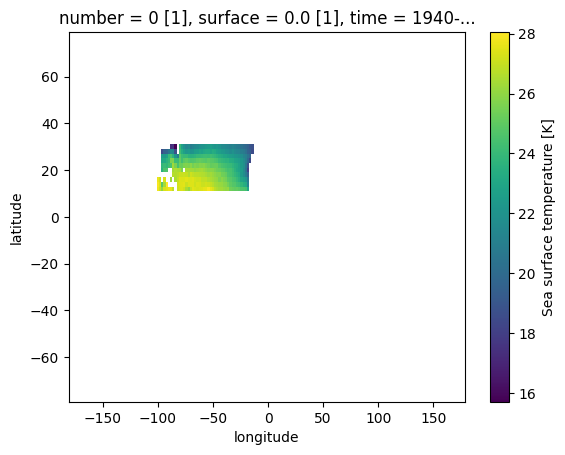

In [4]:
era5_data_2deg.isel(time=0).sst.plot()

In [5]:
mask = era5_data_2deg.sst.notnull().all(dim="time")

#### Load GCM data

In [6]:
os.makedirs(f'outputs/cmip6_models/{model_export}/historical',exist_ok=True)

file_exists = os.path.exists(f'outputs/cmip6_models/{model_export}/historical/sst_{model_export}_historical_2deg_masked.nc')

if file_exists:
    ds_hist_gcm_model_masked_interp = xr.open_dataset(f'outputs/cmip6_models/{model_export}/historical/sst_{model_export}_historical_2deg_masked.nc')

else:

    ds_hist_gcm_model = xr.open_dataset(f'outputs/cmip6_models/{model_export}/historical/sst_{model_export}_historical_regrid.nc')
    ds_hist_gcm_model['longitude'] = np.where(ds_hist_gcm_model['longitude'] > 180, ds_hist_gcm_model['longitude'] - 360, ds_hist_gcm_model['longitude'])

    new_lat = np.arange(-78, 79, 2.0)
    new_lon = np.arange(-180, 180, 2.0)

    ds_hist_gcm_model = ds_hist_gcm_model.chunk({"time": 100, "latitude": 50, "longitude": 50})

    ds_hist_gcm_model_interp = ds_hist_gcm_model.interp(
        latitude=new_lat,
        longitude=new_lon,
        method="linear"
    ).compute()

    ds_hist_gcm_model_interp = ds_hist_gcm_model_interp.ffill("longitude").bfill("longitude")
    ds_hist_gcm_model_interp = ds_hist_gcm_model_interp.ffill("latitude").bfill("latitude")

    ds_hist_gcm_model_interp = ds_hist_gcm_model_interp.sortby('longitude')
    ds_hist_gcm_model_interp = ds_hist_gcm_model_interp.sortby('latitude')

    ds_hist_gcm_model_masked_interp = ds_hist_gcm_model_interp.where(mask)

    ds_hist_gcm_model_masked_interp.to_netcdf(f'outputs/cmip6_models/{model_export}/historical/sst_{model_export}_historical_2deg_masked.nc')

#### Load SSP Data

In [7]:
os.makedirs(f'outputs/cmip6_models/{model_export}/{ssp_export}',exist_ok=True)

file_exists = os.path.exists(f'outputs/cmip6_models/{model_export}/{ssp_export}/sst_{model_export}_{ssp_export}_2deg_masked.nc')

if file_exists:
    ds_proj_gcm_model_masked_interp = xr.open_dataset(f'outputs/cmip6_models/{model_export}/{ssp_export}/sst_{model_export}_{ssp_export}_2deg_masked.nc')

else:

    ds_proj_gcm_model = xr.open_dataset(f'outputs/cmip6_models/{model_export}/{ssp_export}/sst_{model_export}_{ssp_export}_regrid.nc')
    ds_proj_gcm_model['longitude'] = np.where(ds_proj_gcm_model['longitude'] > 180, ds_proj_gcm_model['longitude'] - 360, ds_proj_gcm_model['longitude'])

    new_lat = np.arange(-78, 79, 2.0)
    new_lon = np.arange(-180, 180, 2.0)

    ds_proj_gcm_model = ds_proj_gcm_model.chunk({"time": 100, "latitude": 50, "longitude": 50})

    ds_proj_gcm_model_interp = ds_proj_gcm_model.interp(
        latitude=new_lat,
        longitude=new_lon,
        method="linear"
    ).compute()

    ds_proj_gcm_model_interp = ds_proj_gcm_model_interp.ffill("longitude").bfill("longitude")
    ds_proj_gcm_model_interp = ds_proj_gcm_model_interp.ffill("latitude").bfill("latitude")

    ds_proj_gcm_model_interp = ds_proj_gcm_model_interp.sortby('longitude')
    ds_proj_gcm_model_interp = ds_proj_gcm_model_interp.sortby('latitude')

    ds_proj_gcm_model_masked_interp = ds_proj_gcm_model_interp.where(mask)

    ds_proj_gcm_model_masked_interp.to_netcdf(f'outputs/cmip6_models/{model_export}/{ssp_export}/sst_{model_export}_{ssp_export}_2deg_masked.nc')

In [8]:
start_era5 = era5_data_2deg.time.min().values
end_era5 = era5_data_2deg.time.max().values
start_gcm = ds_hist_gcm_model_masked_interp.time.min().values
end_gcm = ds_hist_gcm_model_masked_interp.time.max().values

start_common = max(start_era5, start_gcm)
end_common = min(end_era5, end_gcm)

#### Bias Correction SST

In [9]:
ds_hist_gcm_model_masked_interp_bias = ds_hist_gcm_model_masked_interp.copy()
ds_proj_gcm_model_masked_interp_bias = ds_proj_gcm_model_masked_interp.copy()

hist_gcm_model_mean = ds_hist_gcm_model_masked_interp_bias["sst"].sel(time=slice(start_common, end_common)).mean(dim="time")
hist_gcm_model_std = ds_hist_gcm_model_masked_interp_bias["sst"].sel(time=slice(start_common, end_common)).std(dim="time")

hist_era5_mean = era5_data_2deg["sst"].sel(time=slice(start_common, end_common)).mean(dim="time")
hist_era5_std = era5_data_2deg["sst"].sel(time=slice(start_common, end_common)).std(dim="time")

ds_hist_gcm_model_masked_interp_bias["sst"] = ((ds_hist_gcm_model_masked_interp_bias["sst"] - hist_gcm_model_mean) / hist_gcm_model_std ) * hist_era5_std + hist_era5_mean
ds_proj_gcm_model_masked_interp_bias["sst"] = ((ds_proj_gcm_model_masked_interp_bias["sst"] - hist_gcm_model_mean) / hist_gcm_model_std ) * hist_era5_std + hist_era5_mean

In [10]:
ds_hist_gcm_model_masked_interp_bias.to_netcdf(f'outputs/cmip6_models/{model_export}/historical/sst_{model_export}_historical_2deg_masked_bias_corrected.nc')
ds_proj_gcm_model_masked_interp_bias.to_netcdf(f'outputs/cmip6_models/{model_export}/{ssp_export}/sst_{model_export}_{ssp_export}_2deg_masked_bias_corrected.nc')